In [70]:
# run this in a NEW notebook cell alone
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())  # should be True on M4
print(f"Memory Allocated: {torch.mps.current_allocated_memory() / 1e9:.2f} GB")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")   


2.12.0
True
Memory Allocated: 0.00 GB
MPS available: True
MPS built: True


In [36]:
# run this alone
import clip
model, preprocess = clip.load("ViT-B/32")
print("CLIP loaded OK")

CLIP loaded OK


In [37]:
import sys, os
sys.path.append(os.path.abspath('../'))
from dotenv import load_dotenv
load_dotenv('../.env')

from src.config import setup_rag_settings
mm_llm = setup_rag_settings()

# now test CLIP index
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core.schema import ImageDocument

test_img = ImageDocument(image_path="../data/DL-Front.png")
index = MultiModalVectorStoreIndex.from_documents([test_img])
print("Index built OK")

/Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/ragenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/ragenv/lib/python3.13/site-packages/llama_index/embeddings/gemini/base.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as gemini


Some nodes are missing content, skipping them...
Index built OK


In [38]:
a=[1,2,3,4]
print(a)
print(type(a))

b=torch.tensor(a)
print(type(b))
print(b)

[1, 2, 3, 4]
<class 'list'>
<class 'torch.Tensor'>
tensor([1, 2, 3, 4])


In [39]:
b.ndim

1

In [40]:
b.shape

torch.Size([4])

In [41]:
TENSOR_1=torch.tensor([[[1, 2, 3,3,9], 
                        [4, 5, 6,4,7], 
                        [7, 8, 9,10,5],
                        [10, 11, 12,11,6],
                        [13, 14, 15,14,8]]])

KERNEL_1=torch.tensor([[[1, 0, 1],
                        [0, 1, 0],
                        [1, 0, 1]]])


In [44]:
print(TENSOR_1.shape)
print(KERNEL_1.shape)

torch.Size([1, 5, 5])
torch.Size([1, 3, 3])


In [45]:
# Reshape to 4D: (N, C_in, H, W) and (C_out, C_in, kH, kW)
TENSOR_1 = TENSOR_1.unsqueeze(0)  # Now [1, 1, 5, 5] (batch=1, channel=1)
KERNEL_1 = KERNEL_1.unsqueeze(1)  # Now [1, 1, 3, 3] (out=1, in=1)

print(TENSOR_1.shape)
print(KERNEL_1.shape)

torch.Size([1, 1, 5, 5])
torch.Size([1, 1, 3, 3])


In [46]:
out_1=torch.nn.functional.conv2d(TENSOR_1, KERNEL_1,padding=0)
print(out_1)

tensor([[[[25, 29, 30],
          [40, 40, 41],
          [55, 58, 48]]]])


In [49]:
TENSOR_1[0]

tensor([[[ 1,  2,  3,  3,  9],
         [ 4,  5,  6,  4,  7],
         [ 7,  8,  9, 10,  5],
         [10, 11, 12, 11,  6],
         [13, 14, 15, 14,  8]]])

In [51]:
KERNEL_2 = torch.tensor([[[[1, 0, 1],
                           [0, 1, 0],
                           [1, 0, 1]]],

                         [[[4, 5, 6],
                           [7, 8, 9],
                           [10,11,12]]]])   

In [53]:
print(KERNEL_2)

tensor([[[[ 1,  0,  1],
          [ 0,  1,  0],
          [ 1,  0,  1]]],


        [[[ 4,  5,  6],
          [ 7,  8,  9],
          [10, 11, 12]]]])


In [59]:
random_tensor= torch.rand(4,3,3) # no, of tensors =4, each of 3x3
random_tensor

tensor([[[0.8564, 0.0329, 0.2967],
         [0.9527, 0.4102, 0.0835],
         [0.3474, 0.6122, 0.6440]],

        [[0.3649, 0.9469, 0.2922],
         [0.9506, 0.5089, 0.9784],
         [0.3823, 0.0889, 0.2500]],

        [[0.3921, 0.8807, 0.3752],
         [0.1389, 0.7492, 0.4156],
         [0.2691, 0.3090, 0.9407]],

        [[0.3717, 0.9325, 0.1117],
         [0.6662, 0.6283, 0.3391],
         [0.7502, 0.4485, 0.6644]]])

In [61]:
# zero tensor

zero_tensor=torch.zeros(4,3,3)
zero_tensor

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [62]:
# one tensor

one_tensor=torch.ones(4,3,3)
one_tensor

tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])

In [107]:
#multipy two tensors

out_2= random_tensor * zero_tensor
out_3= zero_tensor * random_tensor
out_4= one_tensor * zero_tensor
out_5= one_tensor * random_tensor

print(out_2)
print(out_3)
print(out_4)
print(out_5)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
tensor([[[0.8564, 0.0329, 0.2967],
         [0.9527, 0.4102, 0.0835],
         [0.3474, 0.6122, 0.6440]],

        [[0.3649, 0.9469, 0.2922],
      

In [108]:
new_tensor = torch.tensor([[1, 2], [3, 4]],dtype=torch.float,device='mps')

In [109]:
%%time
result = new_tensor * new_tensor # gpu tensor

CPU times: user 299 μs, sys: 74 μs, total: 373 μs
Wall time: 248 μs


In [110]:
import torch

current_memory = torch.mps.current_allocated_memory()  # ✅ Works reliably
driver_memory = torch.mps.driver_allocated_memory()    # ✅ Alternative metric

print(f"Current allocated memory: {current_memory:,} bytes")
print(f"Driver allocated memory: {driver_memory:,} bytes")   


Current allocated memory: 512 bytes
Driver allocated memory: 8,863,744 bytes


In [111]:
new_tensor2 = torch.tensor([[1, 2], [3, 4]],dtype=torch.float,device='cpu')
print(f"Current allocated memory: {current_memory:,} bytes")
new_tensor2

Current allocated memory: 512 bytes


tensor([[1., 2.],
        [3., 4.]])

In [112]:
%%time
result = new_tensor2 * new_tensor2 # cpu tensor

CPU times: user 120 μs, sys: 34 μs, total: 154 μs
Wall time: 140 μs


## v2 chroma checks

In [1]:
import chromadb
print(chromadb.__version__)

1.5.9


In [2]:
client = chromadb.PersistentClient(path="./chroma_db")
print(type(client))

<class 'chromadb.api.client.Client'>


In [3]:
from llama_index.vector_stores.chroma import ChromaVectorStore

text_col = client.get_or_create_collection("rag_text_store")
text_store = ChromaVectorStore(chroma_collection=text_col)
print(type(text_store))
print(text_store._collection.count())

<class 'llama_index.vector_stores.chroma.base.ChromaVectorStore'>
0


In [4]:
image_col = client.get_or_create_collection("rag_image_store")
image_store = ChromaVectorStore(chroma_collection=image_col)
print(image_store._collection.count())

0


In [5]:
from llama_index.core import StorageContext

storage_context = StorageContext.from_defaults(
    vector_store=text_store,
    image_store=image_store,
)
print(storage_context.vector_stores.keys())

dict_keys(['default', 'image'])


In [6]:
import os
from llama_index.core import Settings
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import StorageContext, load_index_from_storage
from llama_index.core.vector_stores import VectorStoreQuery
from llama_index.embeddings.clip import ClipEmbedding

In [7]:
from llama_index.core import Settings
from llama_index.core.vector_stores import VectorStoreQuery

query = "What is the date on my AWS certificate?"

In [8]:
import dotenv
dotenv.load_dotenv("../.env")

True

In [9]:
import sys
sys.path.insert(0, "..")        # so we can import from src/
from src.config import setup_rag_settings

mm_llm = setup_rag_settings()    # ← THIS sets Settings.embed_model = BGE
print("✅ Settings configured")
print("Embed model:", type(__import__('llama_index.core', fromlist=['Settings']).Settings.embed_model).__name__)

/Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/ragenv/lib/python3.13/site-packages/llama_index/llms/gemini/base.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Settings configured
Embed model: HuggingFaceEmbedding


In [10]:
from llama_index.core import Settings
query = "What is the date on my AWS certificate?"

query_emb = Settings.embed_model.get_query_embedding(query)
print("Type:", type(query_emb))
print("Length:", len(query_emb))
print("First 5 numbers:", query_emb[:5])

Type: <class 'list'>
Length: 384
First 5 numbers: [-0.07066652178764343, -0.03922715783119202, -0.002923024585470557, 0.024526476860046387, 0.0325571708381176]


In [11]:
import os
print("Current working directory:", os.getcwd())
print()
print("Looking for chroma_db folders...")
for root, dirs, files in os.walk(".."):
    if "chroma_db" in dirs:
        print("  Found:", os.path.join(root, "chroma_db"))
    if "chroma.sqlite3" in files:
        print("  DB file:", os.path.join(root, "chroma.sqlite3"))

Current working directory: /Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/Shipment(V2)/notebooks

Looking for chroma_db folders...
  Found: ../notebooks/chroma_db
  DB file: ../notebooks/chroma_db/chroma.sqlite3


In [12]:
import shutil
shutil.rmtree("./chroma_db", ignore_errors=True)
shutil.rmtree("../notebooks/chroma_db", ignore_errors=True)

In [13]:
import sys
sys.path.insert(0, "..")
from src.config import setup_rag_settings
mm_llm = setup_rag_settings()
print("✅ Settings ready")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Settings ready


In [14]:
from src.loader import load_documents
textual_data, vision_data = load_documents("../data/", mm_llm)
print(f"\n✅ {len(textual_data)} text docs, {len(vision_data)} image nodes")


==== PDF: GCP.pdf ====
  [OCR used on page 1]
  ✅ 469 chars

==== PDF: Coursera_Structuring_ML_Projects.pdf ====
  ✅ 471 chars

---- Image: STANFORD ONLINE.jpg ----
  ✅ Caption: 2552 chars
  ✅ ImageNode for CLIP

---- Image: Google Technical Fundamentals.png ----
  ✅ Caption: 2648 chars
  ✅ ImageNode for CLIP

---- Image: AZURE -ML STUDIO.png ----
  ✅ Caption: 3447 chars
  ✅ ImageNode for CLIP

==== PDF: Coursera_aws.pdf ====
  ✅ 503 chars

---- Image: GEN_AI-COURSERA.jpeg ----
  ✅ Caption: 3117 chars
  ✅ ImageNode for CLIP

══ Summary: 7 text docs, 4 image nodes ══

✅ 7 text docs, 4 image nodes


In [15]:
from src.loader import load_documents
textual_data, vision_data = load_documents("../data/", mm_llm)
print(f"\n✅ {len(textual_data)} text docs, {len(vision_data)} image nodes")


==== PDF: GCP.pdf ====
  [OCR used on page 1]
  ✅ 469 chars

==== PDF: Coursera_Structuring_ML_Projects.pdf ====
  ✅ 471 chars

---- Image: STANFORD ONLINE.jpg ----
  ✅ Caption: 2643 chars
  ✅ ImageNode for CLIP

---- Image: Google Technical Fundamentals.png ----
  ✅ Caption: 1834 chars
  ✅ ImageNode for CLIP

---- Image: AZURE -ML STUDIO.png ----
  ✅ Caption: 2850 chars
  ✅ ImageNode for CLIP

==== PDF: Coursera_aws.pdf ====
  ✅ 503 chars

---- Image: GEN_AI-COURSERA.jpeg ----
  ✅ Caption: 4450 chars
  ✅ ImageNode for CLIP

══ Summary: 7 text docs, 4 image nodes ══

✅ 7 text docs, 4 image nodes


In [25]:
import os

cwd = os.getcwd()
print("Working directory:", cwd)
print()

chroma_path = os.path.join(cwd, "chroma_db")
print("Checking:", chroma_path)
print("  Exists?    ", os.path.exists(chroma_path))
print("  Is folder? ", os.path.isdir(chroma_path))
print("  Is file?   ", os.path.isfile(chroma_path))   # ← if True, that's the bug

if os.path.isdir(chroma_path):
    print("  Contents:", os.listdir(chroma_path))

# also check write permission
print()
print("Can write here?", os.access(cwd, os.W_OK))

Working directory: /Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/Shipment(V2)/notebooks

Checking: /Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/Shipment(V2)/notebooks/chroma_db
  Exists?     False
  Is folder?  False
  Is file?    False

Can write here? True


In [26]:
import shutil, os, gc

# 1. Force-close any lingering chromadb client holding a lock
gc.collect()

# 2. Remove every possible chroma_db location completely
for path in ["./chroma_db", "../chroma_db", "chroma_db"]:
    if os.path.exists(path):
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        else:
            os.remove(path)
        print(f"Removed: {path}")

print("✅ Clean. chroma_db fully removed.")
print("Current dir:", os.getcwd())
print("chroma_db exists now?", os.path.exists("./chroma_db"))

✅ Clean. chroma_db fully removed.
Current dir: /Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/Shipment(V2)/notebooks
chroma_db exists now? False


In [3]:
import dotenv
dotenv.load_dotenv("../.env")

import os
print("GOOGLE_API_KEY loaded?:", "GOOGLE_API_KEY" in os.environ)
if "GOOGLE_API_KEY" in os.environ:
    print("  starts with:", os.environ["GOOGLE_API_KEY"][:8])

GOOGLE_API_KEY loaded?: True
  starts with: AIzaSyCI


In [4]:
import sys
sys.path.insert(0, "..")
from src.config import setup_rag_settings
mm_llm = setup_rag_settings()
print("✅ Settings ready")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Settings ready


In [5]:
from src.loader import load_documents
textual_data, vision_data = load_documents("../data/", mm_llm)
print(f"\n✅ {len(textual_data)} text docs, {len(vision_data)} image nodes")


==== PDF: GCP.pdf ====
  [OCR used on page 1]
  ✅ 469 chars

==== PDF: Coursera_Structuring_ML_Projects.pdf ====
  ✅ 471 chars

---- Image: STANFORD ONLINE.jpg ----
  ✅ Caption: 3669 chars
  ✅ ImageNode for CLIP

---- Image: Google Technical Fundamentals.png ----
  ✅ Caption: 2093 chars
  ✅ ImageNode for CLIP

---- Image: AZURE -ML STUDIO.png ----
  ✅ Caption: 2908 chars
  ✅ ImageNode for CLIP

==== PDF: Coursera_aws.pdf ====
  ✅ 503 chars

---- Image: GEN_AI-COURSERA.jpeg ----
  ✅ Caption: 2280 chars
  ✅ ImageNode for CLIP

══ Summary: 7 text docs, 4 image nodes ══

✅ 7 text docs, 4 image nodes


In [6]:
from src.engine import build_index
index = build_index(textual_data, vision_data, "../saved_index")

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/7 [00:00<?, ?it/s]


✅ Index built
   ChromaDB path   : ./chroma_db/
   Text vectors    : 7 (BGE 384-dim)
   Image vectors   : 4 (CLIP 512-dim)
   Docstore        : ../saved_index/


In [7]:
text_store = index.storage_context.vector_stores['default']
print("Store type:", type(text_store).__name__)
print("Vectors in store:", text_store._collection.count())

Store type: ChromaVectorStore
Vectors in store: 7


In [8]:
from llama_index.core import Settings
from llama_index.core.vector_stores import VectorStoreQuery

query = "What is the date on my AWS certificate?"

# 1. embed the question with BGE → 384 numbers
query_emb = Settings.embed_model.get_query_embedding(query)

# 2. ask ChromaDB for the 5 nearest vectors
store_query = VectorStoreQuery(query_embedding=query_emb, similarity_top_k=5)
result = text_store.query(store_query)

print("IDs returned:", result.ids)
print("Similarities:", result.similarities)

IDs returned: ['8dfb4785-cf44-42d7-9f9a-710cc7ad0876', '3641c1c9-8342-4999-9c46-110096e29928', 'b833c750-4280-453e-b4de-90233543f2bf', 'd5a4849f-98e8-4d96-b6b6-361bad0cb7d3', 'dd358926-7147-4b58-8c94-7dc34f3301ee']
Similarities: [0.5843371087520186, 0.50738172368226, 0.4886354339975476, 0.4832678154553235, 0.454758901238359]


In [11]:
docstore = index.storage_context.docstore

# what node IDs does the docstore know about?
all_docs = docstore.docs
print("Docstore has", len(all_docs), "nodes")
print("\nDocstore IDs:")
for doc_id in list(all_docs.keys())[:10]:
    node = all_docs[doc_id]
    fn = node.metadata.get('file_name', 'unknown')
    print(f"  {doc_id}  →  {fn}")

print("\nChromaDB returned IDs:")
for nid in result.ids:
    print(f"  {nid}")

Docstore has 0 nodes

Docstore IDs:

ChromaDB returned IDs:
  8dfb4785-cf44-42d7-9f9a-710cc7ad0876
  3641c1c9-8342-4999-9c46-110096e29928
  b833c750-4280-453e-b4de-90233543f2bf
  d5a4849f-98e8-4d96-b6b6-361bad0cb7d3
  dd358926-7147-4b58-8c94-7dc34f3301ee


In [13]:
text_store = index.storage_context.vector_stores['default']

# ChromaDB stores the actual text + metadata — fetch it directly
chroma_data = text_store._collection.get(
    ids=result.ids,
    include=['documents', 'metadatas']
)

print(f"Query: 'What is the date on my AWS certificate?'\n")
for rank, (nid, sim) in enumerate(zip(result.ids, result.similarities), 1):
    # find this id's position in the returned data
    idx = chroma_data['ids'].index(nid)
    doc_text = chroma_data['documents'][idx]
    meta = chroma_data['metadatas'][idx] or {}
    fn = meta.get('file_name', 'unknown')
    preview = doc_text[:70].replace('\n', ' ')
    print(f"#{rank} [{sim:.3f}] {fn}: {preview}...")

Query: 'What is the date on my AWS certificate?'

#1 [0.584] Coursera_aws.pdf: E D U C A T I O N F O R E V E R Y O N E C O U R S E   C E R T I F I C ...
#2 [0.507] GCP.pdf: oO oO COURSE Google Cloud CERTIFICATE Apr 2, 2021 p ZS N F OR & Ne, By...
#3 [0.489] AZURE -ML STUDIO.png: This is a "PROJECT CERTIFICATE" issued by "Coursera" on "Jan 12, 2021"...
#4 [0.483] Google Technical Fundamentals.png: This document is a **Course Certificate** issued jointly by Google and...
#5 [0.455] STANFORD ONLINE.jpg: This document is an online course certificate issued jointly by Stanfo...


In [14]:
# assemble context from ChromaDB results
text_store = index.storage_context.vector_stores['default']
chroma_data = text_store._collection.get(ids=result.ids, include=['documents', 'metadatas'])

context_parts = []
for node_id, sim in zip(result.ids, result.similarities):
    idx = chroma_data['ids'].index(node_id)
    content = chroma_data['documents'][idx]
    meta = chroma_data['metadatas'][idx] or {}
    fn = meta.get('file_name', 'unknown')
    context_parts.append(f"[Source: {fn} | similarity: {sim:.3f}]\n{content}")

context = "\n\n---\n\n".join(context_parts)

# ask Gemini
prompt = (
    "You are answering questions about personal documents.\n\n"
    f"Context:\n{context}\n\n"
    f"Question: What is the date on my AWS certificate?\n\n"
    "Answer based ONLY on the context. Cite the source file."
)
response = Settings.llm.complete(prompt)
print(str(response))

The date on your AWS certificate is 20-Dec-2020. [Source: Coursera_aws.pdf]


In [1]:
# restart kernel, then:
import dotenv; dotenv.load_dotenv("../.env")
import sys; sys.path.insert(0, "..")
from src.config import setup_rag_settings
from src.engine import load_index, ask_query

mm_llm = setup_rag_settings()
index = load_index("../saved_index")

print(ask_query(index, "What is the date on my AWS certificate?"))
print("---")
print(ask_query(index, "List all my certificates with their dates"))

/Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/ragenv/lib/python3.13/site-packages/llama_index/llms/gemini/base.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Index loaded
   Text vectors  : 7
   Image vectors : 4
🔍 Text retrieval mode (ChromaDB)

The date on your AWS certificate is 20-Dec-2020. (Source: Coursera_aws.pdf)
---
🔍 Text retrieval mode (ChromaDB)

Here are your certificates with their dates:

*   **Course Certificate** (Technical Support Fundamentals) - Nov 1, 2020 (Source: Google Technical Fundamentals.png)
*   **COURSE CERTIFICATE** (Google Cloud Platform Big Data and Machine Learning Fundamentals) - Apr 2, 2021 (Source: GCP.pdf)
*   **Online Course Certificate** (Machine Learning) - Apr 26, 2021 (Source: STANFORD ONLINE.jpg)
*   **COURSE CERTIFICATE** (AWS Fundamentals: Going Cloud-Native) - 20-Dec-2020 (Source: Coursera_aws.pdf)
*   **Coursera Project Certificate** (Machine Learning Pipelines with Azure ML Studio) - Jan 12, 2021 (Source: AZURE -ML STUDIO.png)


In [4]:
image_store = index.storage_context.vector_stores['image']
chroma_data = image_store._collection.get(include=['metadatas'])
print("Image metadata stored in ChromaDB:")
for i, meta in enumerate(chroma_data['metadatas']):
    print(f"  {i+1}: {meta}")

Image metadata stored in ChromaDB:
  1: {'_node_type': 'ImageNode', 'doc_id': 'None', 'document_id': 'None', 'source_type': 'image', 'ref_doc_id': 'None', 'file_name': 'STANFORD ONLINE.jpg', '_node_content': '{"id_": "35232720-af75-4fde-9326-2e81dafe20ef", "embedding": null, "metadata": {"file_name": "STANFORD ONLINE.jpg", "source_type": "image"}, "excluded_embed_metadata_keys": [], "excluded_llm_metadata_keys": [], "relationships": {}, "metadata_template": "{key}: {value}", "metadata_separator": "\\n", "text": "", "mimetype": "text/plain", "start_char_idx": null, "end_char_idx": null, "text_template": "{metadata_str}\\n\\n{content}", "image": null, "image_path": "../data/STANFORD ONLINE.jpg", "image_url": null, "image_mimetype": "image/jpeg", "text_embedding": null, "class_name": "ImageNode"}'}
  2: {'ref_doc_id': 'None', 'source_type': 'image', 'file_name': 'Google Technical Fundamentals.png', '_node_type': 'ImageNode', '_node_content': '{"id_": "645dcff3-85ee-4989-9bef-3b223f66b106"

In [2]:
ask_query(index, "Find the certificate signed by Andrew Ng")

🔍 Text retrieval mode (ChromaDB)



'Andrew Ng is not mentioned as a signatory, instructor, or authorizer in any of the provided documents.'

In [3]:
from llama_index.core import Settings
from llama_index.core.vector_stores import VectorStoreQuery

query = "Find the certificate signed by Andrew Ng"
query_emb = Settings.embed_model.get_query_embedding(query)

text_store = index.storage_context.vector_stores['default']

# get ALL 7 documents ranked
result = text_store.query(VectorStoreQuery(query_embedding=query_emb, similarity_top_k=7))
data = text_store._collection.get(ids=result.ids, include=['documents', 'metadatas'])

print(f"ALL 7 RANKED RESULTS:\n")
for rank, (nid, sim) in enumerate(zip(result.ids, result.similarities), 1):
    idx = data['ids'].index(nid)
    fn = (data['metadatas'][idx] or {}).get('file_name', '?')
    doc = data['documents'][idx] or ''
    has_ng = 'andrew ng' in doc.lower()
    print(f"#{rank} [{sim:.4f}] {fn}  {'✅ HAS ANDREW NG' if has_ng else ''}")

ALL 7 RANKED RESULTS:

#1 [0.5290] GCP.pdf  
#2 [0.5144] Google Technical Fundamentals.png  
#3 [0.4931] GEN_AI-COURSERA.jpeg  
#4 [0.4919] Coursera_aws.pdf  
#5 [0.4812] AZURE -ML STUDIO.png  
#6 [0.4797] STANFORD ONLINE.jpg  ✅ HAS ANDREW NG
#7 [0.4491] Coursera_Structuring_ML_Projects.pdf  ✅ HAS ANDREW NG


In [4]:
from src.engine import _text_query

result = _text_query(index, "Find the certificate signed by Andrew Ng", top_k=7)
print(result)

🔍 Text retrieval mode (ChromaDB)

Andrew Ng signed two certificates:

*   The **Machine Learning** course certificate, where he is listed as Associate Professor, Computer Science Department, Stanford University. This certificate was issued on Apr 26, 2021, to Deepak Rathore. [Source: STANFORD ONLINE.jpg]
*   The **Structuring Machine Learning Projects** course certificate, where he is listed as Adjunct Professor, Computer Science. This certificate was issued on Oct 25, 2020, to DEEPAK RATHORE. [Source: Coursera_Structuring_ML_Projects.pdf]


In [7]:
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.core.vector_stores import VectorStoreQuery
import numpy as np

query = "Show me images that look like certificates"

# 1. embed the query with CLIP
clip = ClipEmbedding()
query_emb = clip.get_query_embedding(query)

print(f"Query vector length : {len(query_emb)}")
print(f"Query vector norm   : {np.linalg.norm(query_emb):.6f}")
print(f"First 5 values      : {query_emb[:5]}")
print()

# 2. manually compute cosine similarity vs stored vectors
image_store = index.storage_context.vector_stores['image']
stored = image_store._collection.get(include=['embeddings', 'metadatas'])

q = np.array(query_emb)
for i, (emb, meta) in enumerate(zip(stored['embeddings'], stored['metadatas'])):
    v = np.array(emb)
    cosine = np.dot(q, v) / (np.linalg.norm(q) * np.linalg.norm(v))
    fn = (meta or {}).get('file_name', '?')
    print(f"  {fn}: cosine={cosine:.4f}")

print()
# 3. now query through ChromaDB and see what it returns
result = image_store.query(VectorStoreQuery(query_embedding=query_emb, similarity_top_k=4))
print(f"ChromaDB returned similarities: {result.similarities}")

Query vector length : 512
Query vector norm   : 10.761754
First 5 values      : [0.5086385607719421, -0.23447445034980774, 0.1381940245628357, -0.27879104018211365, 0.23012013733386993]

  STANFORD ONLINE.jpg: cosine=0.2835
  Google Technical Fundamentals.png: cosine=0.3117
  AZURE -ML STUDIO.png: cosine=0.2911
  GEN_AI-COURSERA.jpeg: cosine=0.2896

ChromaDB returned similarities: [4.43883650130725e-57, 3.9532877176017826e-57, 1.0377996514046834e-58, 7.992618365817394e-59]


/Users/deepakrathore/Documents/Agentic-AI/Examples/OWN RAG(LLAMA)/ragenv/lib/python3.13/site-packages/llama_index/llms/gemini/base.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Index loaded
   Text vectors  : 7
   Image vectors : 4
🖼️  Visual similarity mode (ChromaDB + CLIP)

Top 2 visually similar images:

--- MATCH 1 (CLIP similarity: 0.000) ---
  File: Google Technical Fundamentals.png


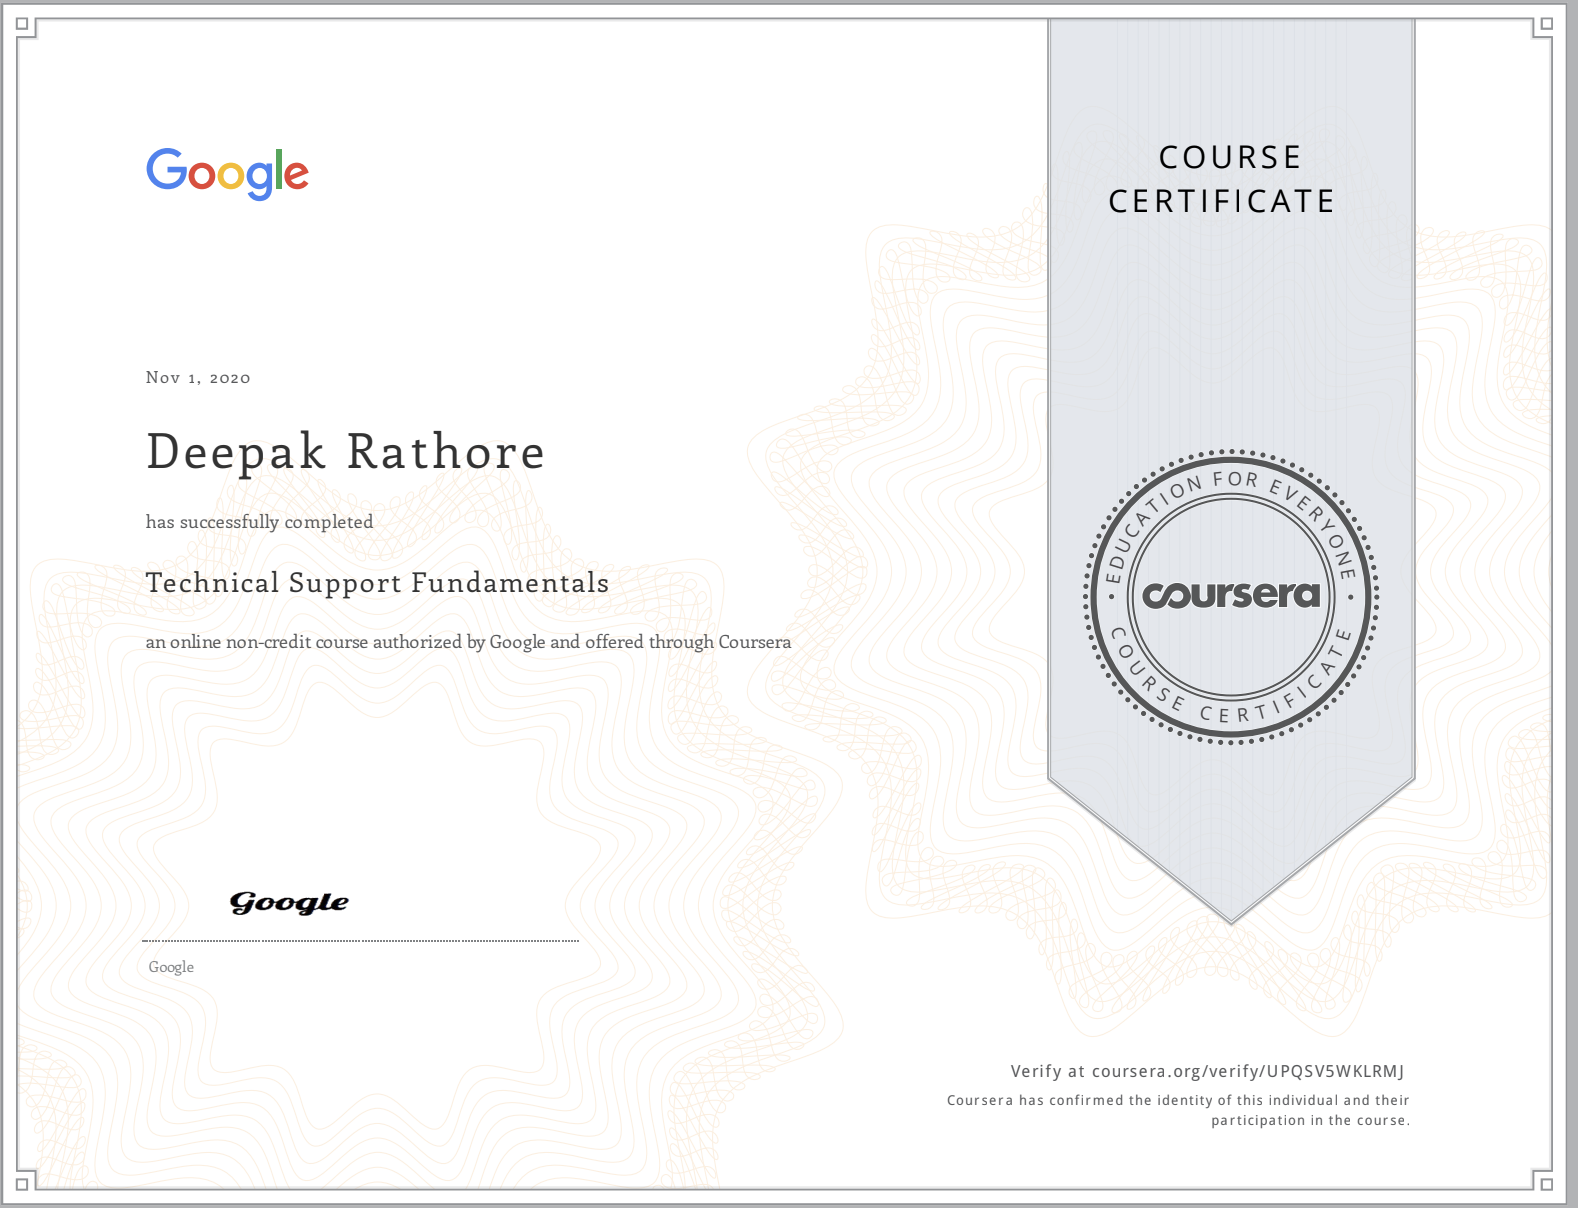


--- MATCH 2 (CLIP similarity: 0.000) ---
  File: AZURE -ML STUDIO.png


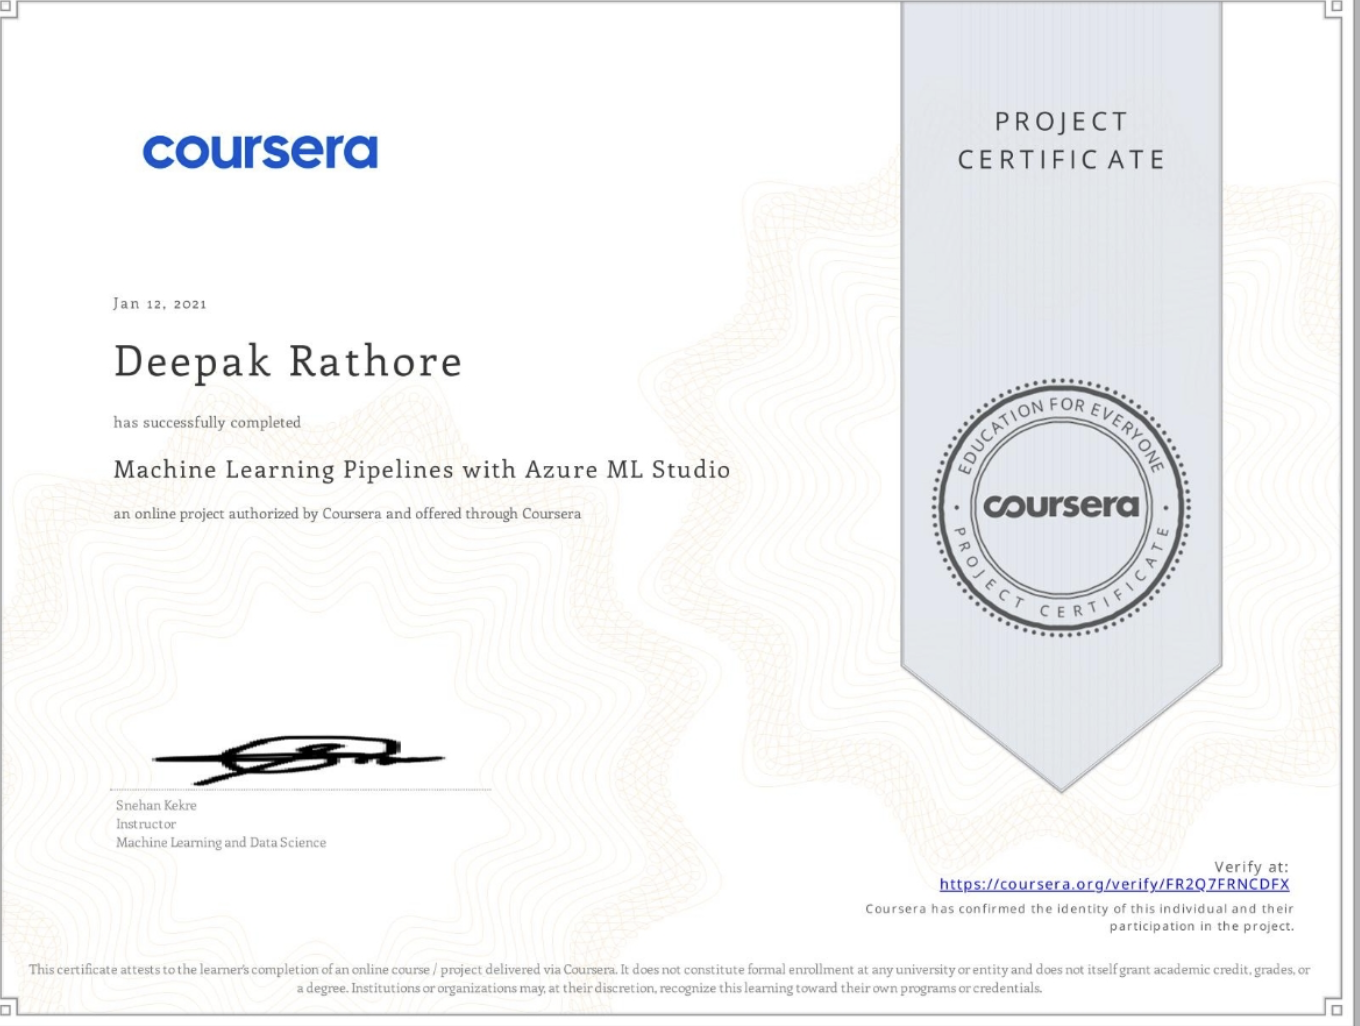

[('Google Technical Fundamentals.png', 4.43883650130725e-57),
 ('AZURE -ML STUDIO.png', 3.9532877176017826e-57)]

In [1]:
import dotenv; dotenv.load_dotenv("../.env")
import sys; sys.path.insert(0, "..")
from src.config import setup_rag_settings
from src.engine import load_index, ask_query
mm_llm = setup_rag_settings()
index = load_index("../saved_index")

ask_query(index, "Show me images that look like certificates")